In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sudiponmakal
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:01<00:00, 127MB/s]


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 25

In [ ]:
train_dir = "brain-tumor-mri-dataset/Training"
test_dir  = "brain-tumor-mri-dataset/Testing"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print(class_names)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


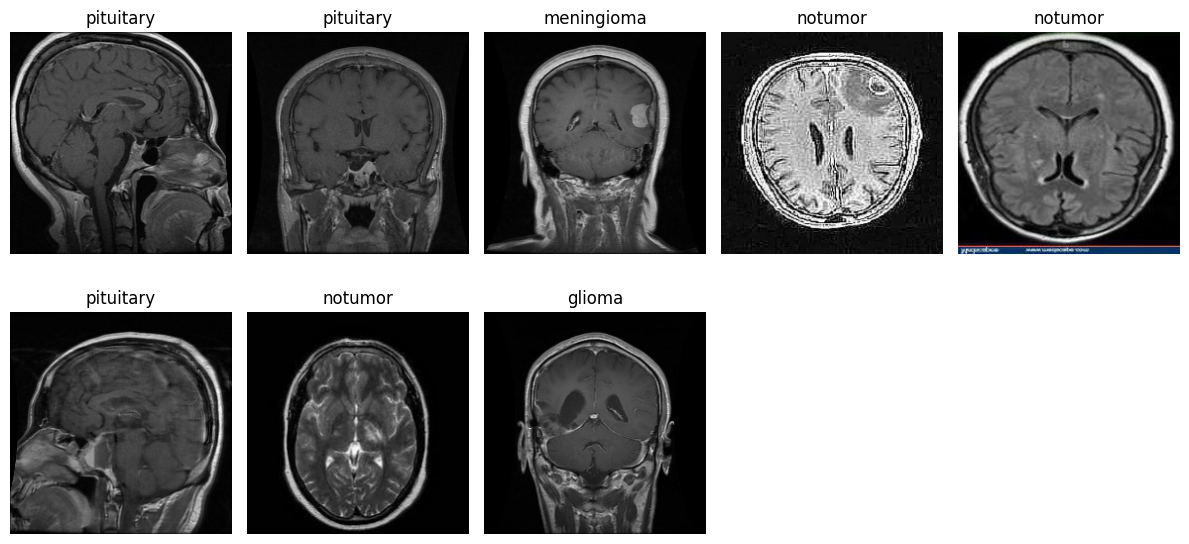

In [ ]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_ds))
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label = class_names[tf.argmax(labels[i]).numpy()]
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def clahe_preprocess(image, label):

    def process(img):
        img = img.numpy().astype(np.uint8)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)

        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

        return enhanced

    image = tf.map_fn(
        lambda x: tf.py_function(process,[x],tf.uint8),
        image,
        fn_output_signature=tf.uint8
    )

    image.set_shape((None,224,224,3))

    return image, label

In [ ]:
train_ds = train_ds.map(clahe_preprocess)
test_ds  = test_ds.map(clahe_preprocess)

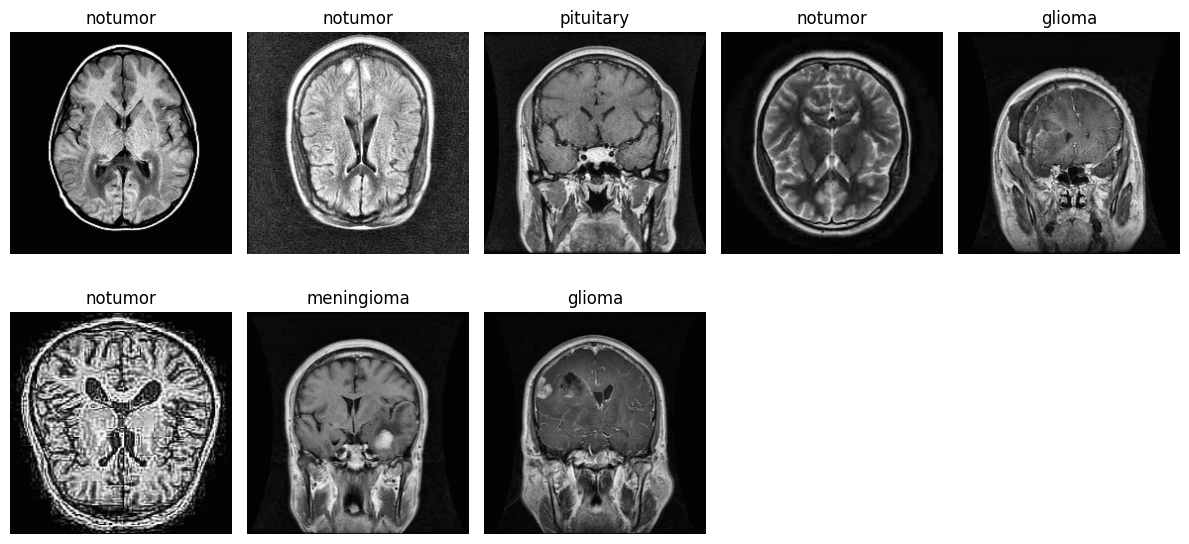

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label = class_names[tf.argmax(labels[i]).numpy()]
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_ds = train_ds.map(lambda x,y: (preprocess_input(x),y))
test_ds  = test_ds.map(lambda x,y: (preprocess_input(x),y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
data_aug = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),

    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.2)

])

In [ ]:
base_model = MobileNetV3Large(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = data_aug(base_model.input)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.1)(x)

outputs = layers.Dense(4, activation="softmax", dtype="float32")(x)

model = models.Model(base_model.input, outputs)

In [ ]:
loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=loss,
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
)

Epoch 1/25
700/700 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7337 - loss: 0.8660 - val_accuracy: 0.8012 - val_loss: 0.7601
Epoch 2/25
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8157 - loss: 0.7288 - val_accuracy: 0.8031 - val_loss: 0.7617
Epoch 3/25
700/700 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.8391 - loss: 0.6860 - val_accuracy: 0.8144 - val_loss: 0.7300
Epoch 4/25
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8561 - loss: 0.6602 - val_accuracy: 0.8288 - val_loss: 0.7022
Epoch 5/25
700/700 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8650 - loss: 0.6377 - val_accuracy: 0.8156 - val_loss: 0.7471
Epoch 6/25
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8704 - loss: 0.6222 - val_accuracy: 0.8200 - val_loss: 0.7364
Epoch 7/25
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8761 - loss: 0.6142 - val_accuracy: 0.8419 - val_loss: 0.6845
Epoch 8/25
700/700 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.8820 - loss: 0.6035 - 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_acc*100:.4f}%")

200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8763 - loss: 0.6295
Final Test Accuracy: 87.6250%


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


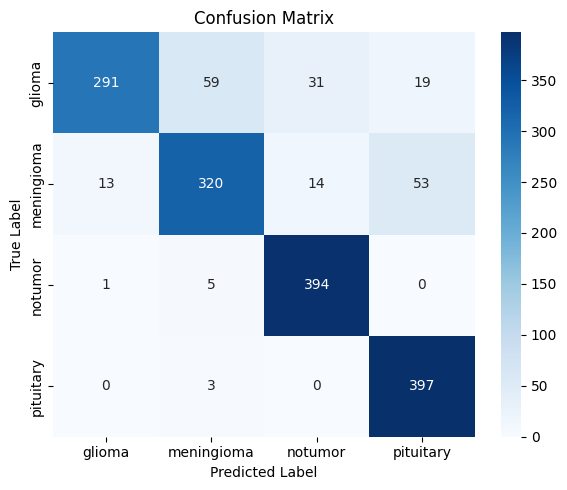

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

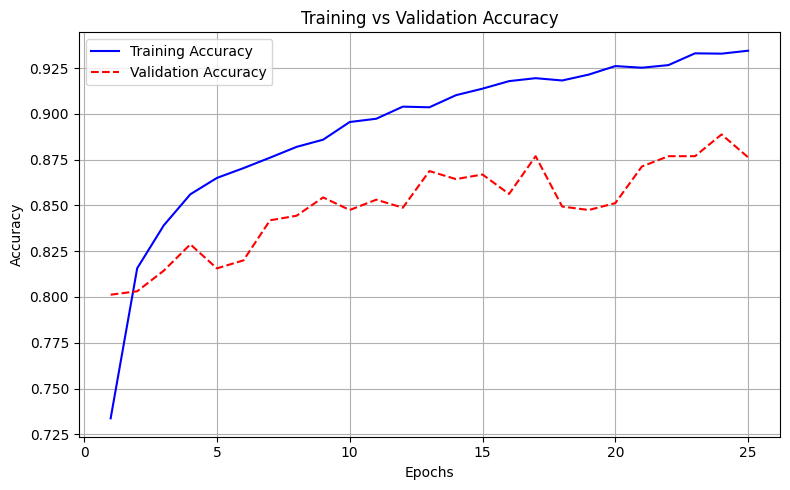

In [ ]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
model.save("brain_tumor_moDEL.keras")

print("Model saved successfully")

Model saved successfully


In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       492,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,877,198 (18.61 MB)

 Trainable params: 626,308 (2.39 MB)

 Non-trainable params: 2,998,272 (11.44 MB)

 Optimizer params: 1,252,618 (4.78 MB)

Select up to 12 MRI images


Saving BRAIN.jpg to BRAIN (1).jpg
Saving BRAIN2.jpg to BRAIN2 (1).jpg
Saving BRAIN3.jpg to BRAIN3 (1).jpg


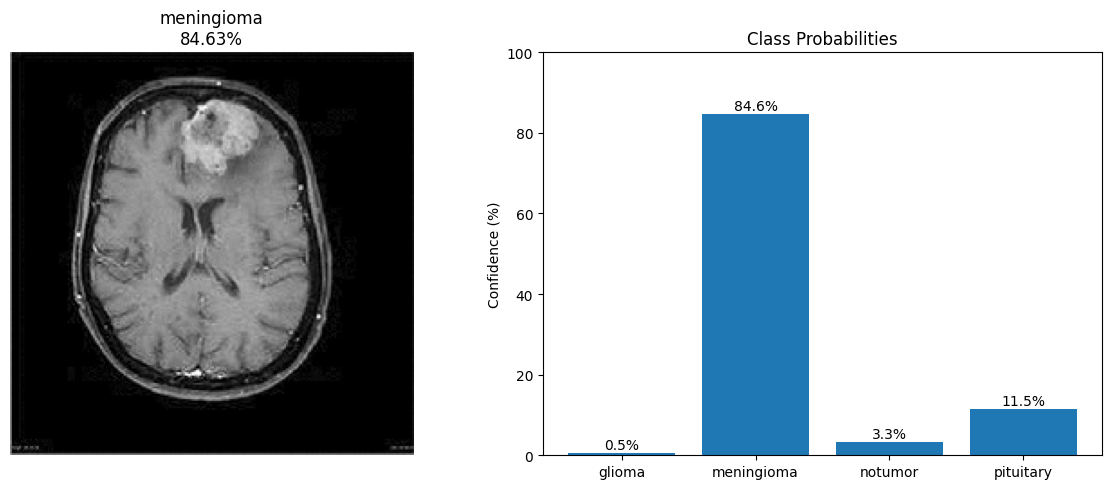

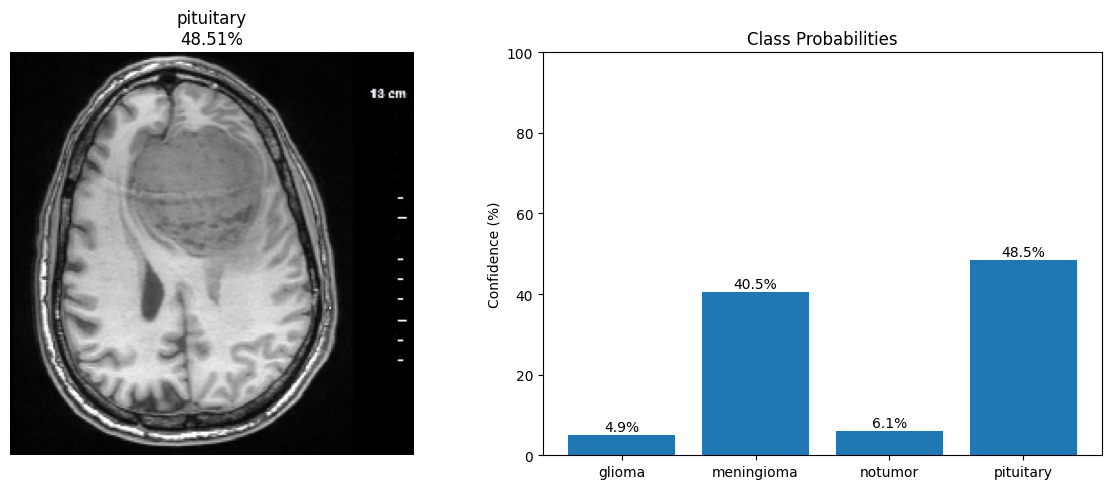

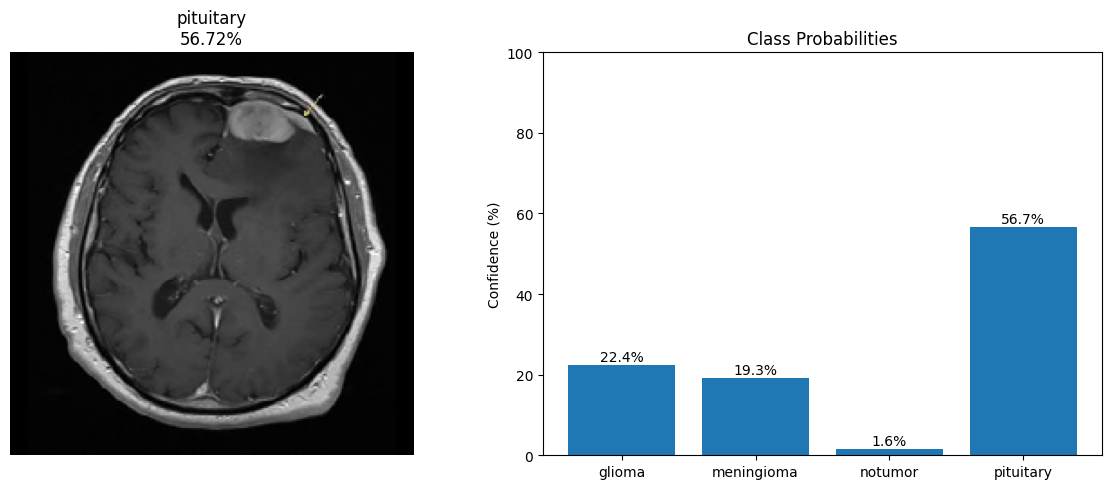

In [ ]:
from google.colab import files
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================
# LOAD MODEL
# ==========================

model = tf.keras.models.load_model(
    "brain_tumor_moDEL.keras"
)

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

# ==========================
# SELECT IMAGES
# ==========================

print("Select up to 12 MRI images")

uploaded = files.upload()

image_files = list(uploaded.keys())

if len(image_files) == 0:
    raise ValueError("No image selected")

if len(image_files) > 12:
    raise ValueError(
        f"Maximum 12 images allowed. Selected {len(image_files)}."
    )

# ==========================
# PREDICT
# ==========================

for image_path in image_files:

    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = tf.keras.utils.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Uncomment if used during training
    # from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
    # img_array = preprocess_input(img_array)

    pred = model.predict(
        img_array,
        verbose=0
    )[0]

    predicted_class = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{predicted_class}\n{confidence:.2f}%"
    )

    plt.subplot(1,2,2)
    bars = plt.bar(
        class_names,
        pred * 100
    )

    plt.ylim(0,100)
    plt.ylabel("Confidence (%)")
    plt.title("Class Probabilities")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}%",
            ha="center"
        )

    plt.tight_layout()
    plt.show()